# KNN Classification: Iris Species Predictor

This notebook details the application of the K-Nearest Neighbors (KNN) algorithm to classify iris flowers into their respective species (setosa, versicolor, and virginica).

### Key steps:
1. Ingesting features from SQLite with CSV fallback.
2. Exploratory Data Analysis (EDA) and range visualization.
3. Feature preprocessing and stratified train-test splitting (avoiding data leakage).
4. Hyperparameter tuning (evaluating performance across multiple values of $K$).
5. 2D decision boundary visualization.
6. Evaluation of final model using precision, recall, and a confusion matrix.


In [1]:
import os
import sqlite3
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

sns.set_theme(style="whitegrid")
%matplotlib inline


## 1. Data Ingestion
We pull the dataset from the SQLite database. If that fails (e.g. database path or driver issues), we fall back to loading the CSV.


In [2]:
def load_data(sqlite_path="../database.sqlite", csv_path="../dataset/iris.csv"):
    if os.path.exists(sqlite_path):
        try:
            conn = sqlite3.connect(sqlite_path)
            df = pd.read_sql_query("SELECT * FROM Iris", conn)
            conn.close()
            print(f"Loaded {len(df)} records from database: {sqlite_path}")
            return df
        except Exception as err:
            print(f"Database query failed ({err}). Falling back to CSV.")
            
    if os.path.exists(csv_path):
        df = pd.read_csv(csv_path)
        print(f"Loaded {len(df)} records from CSV: {csv_path}")
        return df
        
    raise FileNotFoundError("Missing SQLite database and CSV dataset files.")

df = load_data()
df.head()


Loaded 150 records from database: ../database.sqlite


,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


## 2. Exploratory Data Analysis (EDA)
Check the dataset size, data types, missing values, duplicates, and general summary statistics.


In [3]:
print(f"Shape: {df.shape}")
print(f"Duplicates: {df.duplicated().sum()}")
print(f"Missing values:\n{df.isnull().sum()}\n")
df.describe()


Shape: (150, 6)
Duplicates: 0
Missing values:
Id               0
SepalLengthCm    0
SepalWidthCm     0
PetalLengthCm    0
PetalWidthCm     0
Species          0
dtype: int64



,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,75.500000,5.843333,3.054000,3.758667,1.198667
std,43.445368,0.828066,0.433594,1.764420,0.763161
min,1.000000,4.300000,2.000000,1.000000,0.100000
25%,38.250000,5.100000,2.800000,1.600000,0.300000
50%,75.500000,5.800000,3.000000,4.350000,1.300000
75%,112.750000,6.400000,3.300000,5.100000,1.800000
max,150.000000,7.900000,4.400000,6.900000,2.500000


### Feature Distributions and Class Mappings
Let's see how balanced the species count is and look at pairwise relationships to observe clustering trends.


C:\Users\user\AppData\Local\Temp\ipykernel_21612\4043529896.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x="Species", palette="viridis")


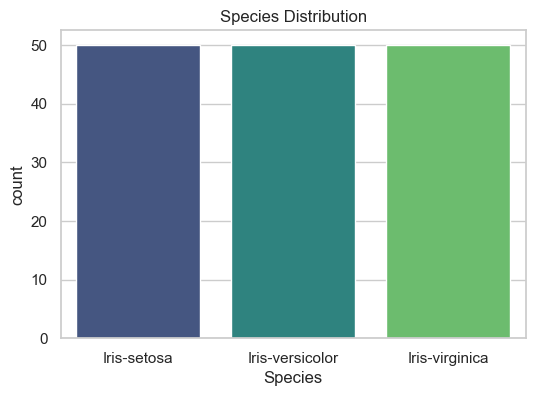

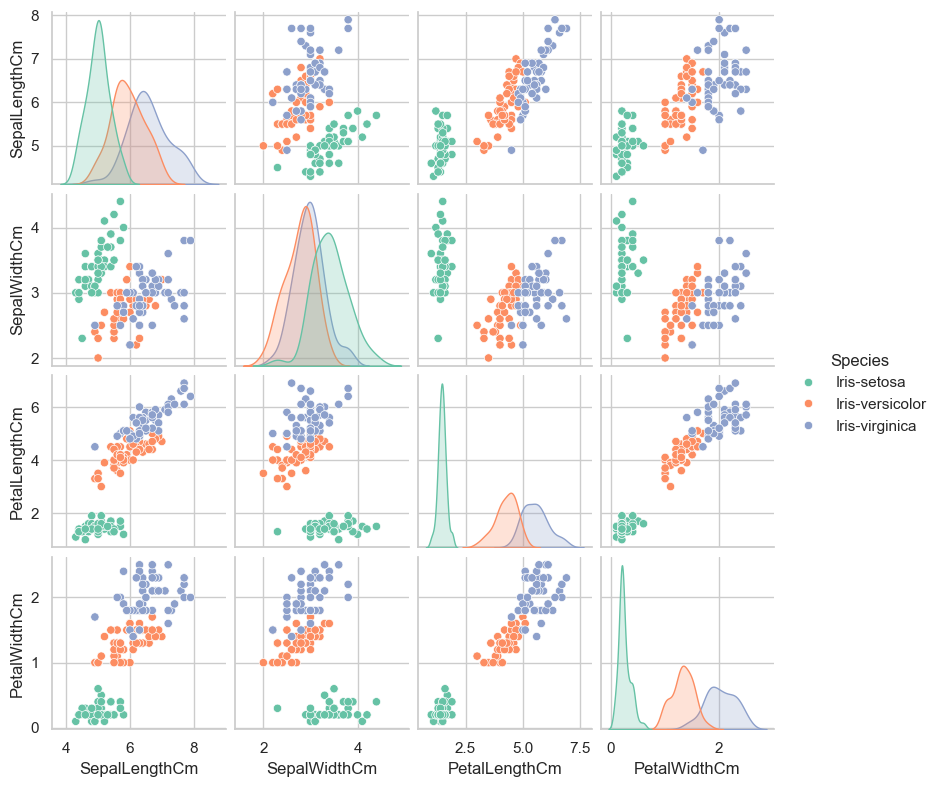

In [4]:
# Species count distribution
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x="Species", palette="viridis")
plt.title("Species Distribution")
plt.show()

# Pairwise scatter relationships
df_features = df.drop(columns=["Id"], errors="ignore")
sns.pairplot(df_features, hue="Species", palette="Set2", height=2.0)
plt.show()


### Feature Correlation
We look at correlation metrics to identify feature redundancies.


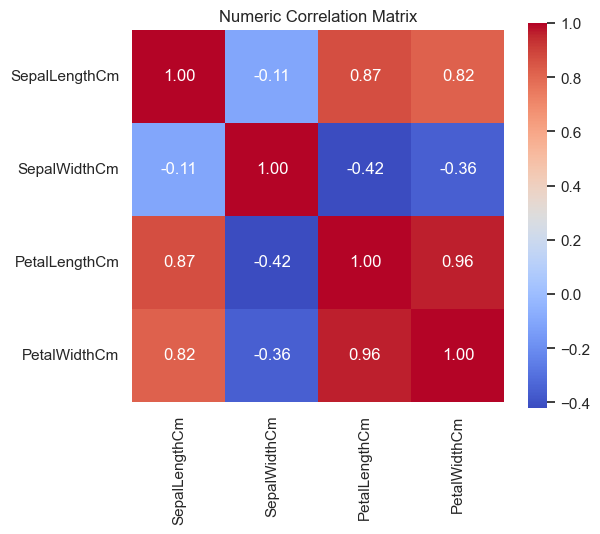

In [5]:
plt.figure(figsize=(6, 5))
numeric_df = df_features.select_dtypes(include=[np.number])
sns.heatmap(numeric_df.corr(), annot=True, cmap="coolwarm", fmt=".2f", square=True)
plt.title("Numeric Correlation Matrix")
plt.show()


## 3. Data Preprocessing
Here we clean up duplicates, separate features from the targets, encode species labels, split data into an 80/20 train/test partition, and standardize features. We fit the scaler strictly on `X_train` to prevent data leakage.


In [6]:
df_clean = df.drop_duplicates()

X = df_clean.drop(columns=["Id", "Species"], errors="ignore")
y = df_clean["Species"]

encoder = LabelEncoder()
y_encoded = encoder.fit_transform(y)
class_names = list(encoder.classes_)

X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Train features: {X_train_scaled.shape}, Test features: {X_test_scaled.shape}")


Train features: (120, 4), Test features: (30, 4)


## 4. Hyperparameter Comparison (K-Value Selection)
We compare classification accuracy across multiple neighborhood values $K \in \{1, 3, 5, 7, 9, 11\}$ to find the best compromise between bias and variance.


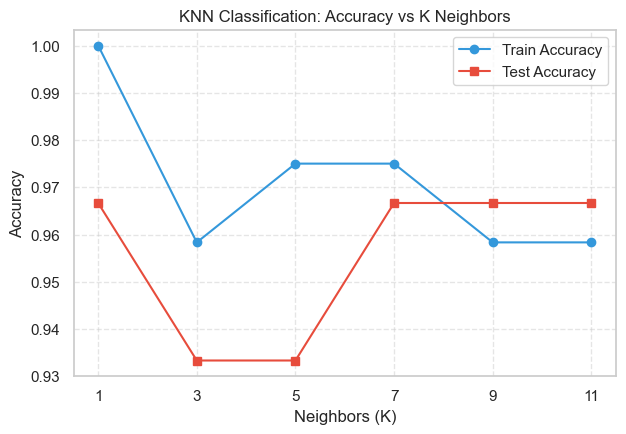

Optimal selected parameter: K = 11 (Test Accuracy = 0.9667)


In [7]:
k_choices = [1, 3, 5, 7, 9, 11]
train_scores = []
test_scores = []

for k in k_choices:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_scaled, y_train)
    train_scores.append(accuracy_score(y_train, knn.predict(X_train_scaled)))
    test_scores.append(accuracy_score(y_test, knn.predict(X_test_scaled)))

plt.figure(figsize=(7, 4.5))
plt.plot(k_choices, train_scores, marker="o", label="Train Accuracy", color="#3498db")
plt.plot(k_choices, test_scores, marker="s", label="Test Accuracy", color="#e74c3c")
plt.title("KNN Classification: Accuracy vs K Neighbors")
plt.xlabel("Neighbors (K)")
plt.ylabel("Accuracy")
plt.xticks(k_choices)
plt.legend()
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()

# Find the best performing K (using larger K as tie-breaker for smoother decision boundary)
best_k = k_choices[0]
best_score = -1.0
for k, score in zip(k_choices, test_scores):
    if score > best_score or (score == best_score and k > best_k):
        best_score = score
        best_k = k
        
print(f"Optimal selected parameter: K = {best_k} (Test Accuracy = {best_score:.4f})")


## 5. 2D Decision Boundaries
We fit KNN classifiers on Petal features (`PetalLengthCm` and `PetalWidthCm`) to visualize decision boundary regions in standardized 2D space.


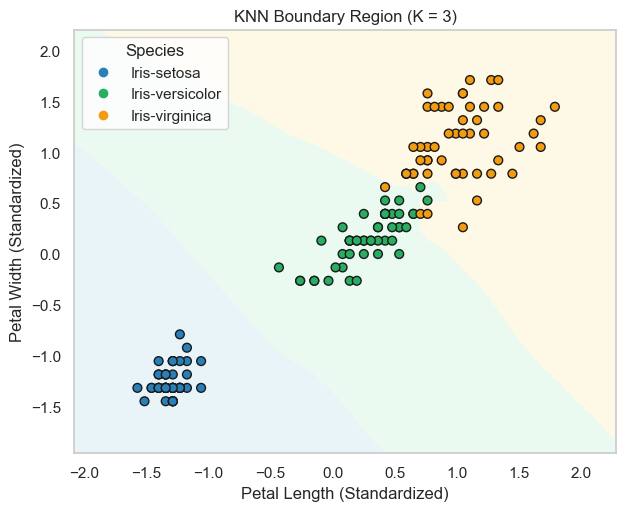

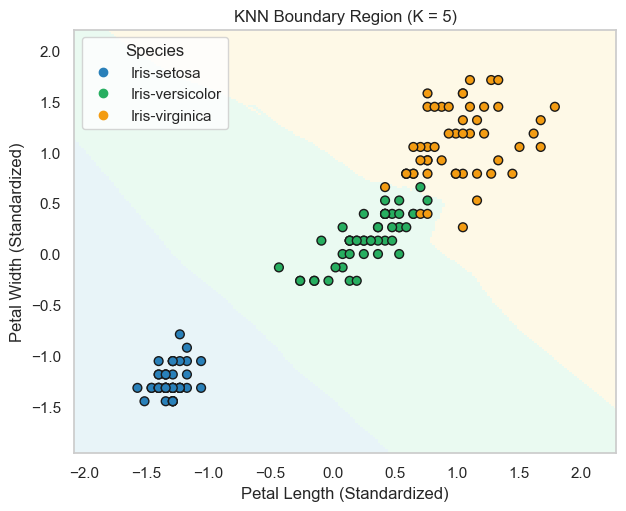

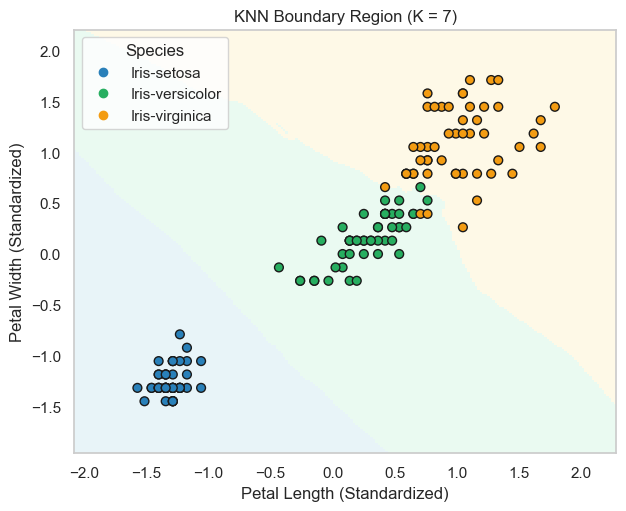

In [8]:
X_2d = df_clean[["PetalLengthCm", "PetalWidthCm"]].values
scaler_2d = StandardScaler()
X_scaled_2d = scaler_2d.fit_transform(X_2d)

x_min, x_max = X_scaled_2d[:, 0].min() - 0.5, X_scaled_2d[:, 0].max() + 0.5
y_min, y_max = X_scaled_2d[:, 1].min() - 0.5, X_scaled_2d[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02), np.arange(y_min, y_max, 0.02))

from matplotlib.colors import ListedColormap
cmap_bg = ListedColormap(["#e8f4f8", "#eafaf1", "#fef9e7"])
cmap_fg = ListedColormap(["#2980b9", "#27ae60", "#f39c12"])

for k in [3, 5, 7]:
    knn_2d = KNeighborsClassifier(n_neighbors=k)
    knn_2d.fit(X_scaled_2d, y_encoded)
    
    Z = knn_2d.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
    
    plt.figure(figsize=(7, 5.5))
    plt.pcolormesh(xx, yy, Z, cmap=cmap_bg, shading="auto")
    scatter = plt.scatter(X_scaled_2d[:, 0], X_scaled_2d[:, 1], c=y_encoded, cmap=cmap_fg, edgecolors="k", s=40)
    plt.title(f"KNN Boundary Region (K = {k})")
    plt.xlabel("Petal Length (Standardized)")
    plt.ylabel("Petal Width (Standardized)")
    plt.legend(handles=scatter.legend_elements()[0], labels=class_names, loc="upper left", title="Species")
    plt.show()


## 6. Final Model Evaluation
We retrain our model using the optimal $K$ neighbors on all four standardized features. We check overall accuracy, precision, recall, and class confusion.


Optimal Model Accuracy (K=11): 0.9667

Classification Report:
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       1.00      0.90      0.95        10
 Iris-virginica       0.91      1.00      0.95        10

       accuracy                           0.97        30
      macro avg       0.97      0.97      0.97        30
   weighted avg       0.97      0.97      0.97        30



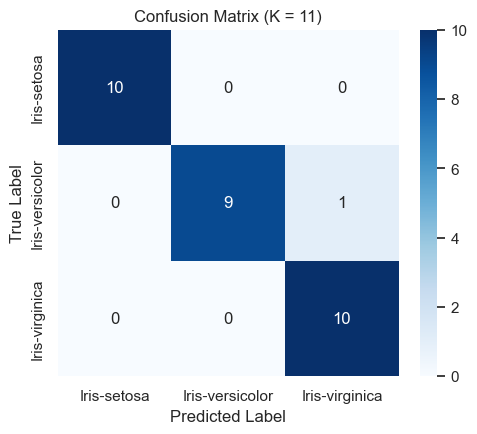

In [9]:
final_model = KNeighborsClassifier(n_neighbors=best_k)
final_model.fit(X_train_scaled, y_train)
y_pred = final_model.predict(X_test_scaled)

print(f"Optimal Model Accuracy (K={best_k}): {accuracy_score(y_test, y_pred):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=class_names))

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5.5, 4.5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=class_names, yticklabels=class_names)
plt.title(f"Confusion Matrix (K = {best_k})")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()


## 7. Model Serialization
We save our trained model and preprocessing pipeline together for production use.


In [10]:
model_payload = {
    "model": final_model,
    "scaler": scaler,
    "features": list(X.columns),
    "classes": class_names
}
joblib.dump(model_payload, "../models/knn_classifier.pkl")
print("Saved classifier payload to models/knn_classifier.pkl")


Saved classifier payload to models/knn_classifier.pkl
